In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()

In [4]:
x = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [23]:
x = (x - x.mean()) / x.std()


In [24]:
m, n = x.shape
# m -> number of training examples
# n -> numbers of features
print("Examples:",m)
print("Features:",n)

Examples: 569
Features: 30


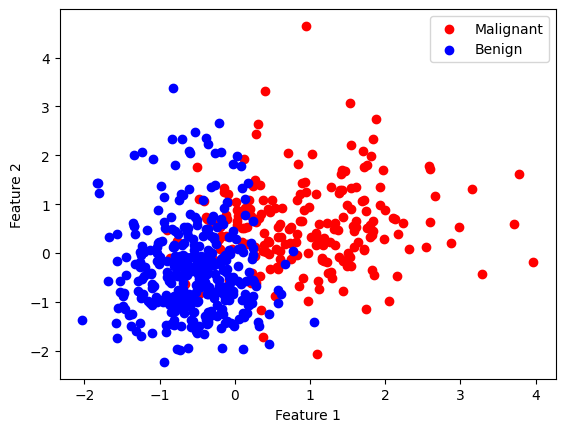

In [25]:
plt.scatter(
    x.loc[y==0].iloc[:,0],
    x.loc[y==0].iloc[:,1],
    color='red', label='Malignant'
)

plt.scatter(
    x.loc[y==1].iloc[:,0],
    x.loc[y==1].iloc[:,1],
    color='blue', label='Benign'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [26]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))
# g(z) = 1/ (1 + e^(-z))

In [31]:
def cost_function(x,y,w,b):
    cost = 0
    epsilon = 1e-15
    
    for i in range(m):
        z = np.dot(w,x[i])+b
        f = sigmoid(z)
        f = np.clip(f, epsilon, 1 - epsilon)
        cost += y[i]*np.log(f) - (1-y[i])*np.log(1-f)
        
    return cost / m    

In [32]:
def gradient_function(x,y,w,b):
    grad_w = np.zeros(n)
    grad_b = 0
    
    for i in range(m):
        z = np.dot(w, x[i]+b)
        f = sigmoid(z)
        
        error = f - y[i]
        
        grad_b += error
        
        for j in range(n):
            grad_w[j] += error * x[i][j]
            
    grad_w = grad_w / m
    grad_b = grad_b / m
    
    return grad_w, grad_b        

In [33]:
def gradient_descent(x, y, alpha, iterations):
    w = np.zeros(n)
    b = 0
    for i in range(iterations):
        grad_w, grad_b = gradient_function(x,y,w,b)
        w = w - alpha * grad_w
        b = b - alpha * grad_b
        
        if i%100==0:
            print("Cost:",cost_function(x,y,w,b))
    return w,b        

In [34]:
learning_rate = 0.01
iterations = 1000

w,b = gradient_descent(
    x.values,
    y.values,
    learning_rate,
    iterations
)

Cost: -0.17591305739013038
Cost: -0.07101903521472606
Cost: -0.023095159623708946
Cost: 0.015737503798962296
Cost: 0.04960166036523521
Cost: 0.06970147811140584
Cost: 0.08667123659814899
Cost: 0.10329614093896311
Cost: 0.11984055849813681
Cost: 0.1363517645007971


In [35]:
z = x.values.dot(w)+b
preds = (sigmoid(z) >= 0.5).astype(int)


In [36]:
accuracy = np.mean(preds == y.values)
print("Accuracy:", accuracy)


Accuracy: 0.9402460456942003


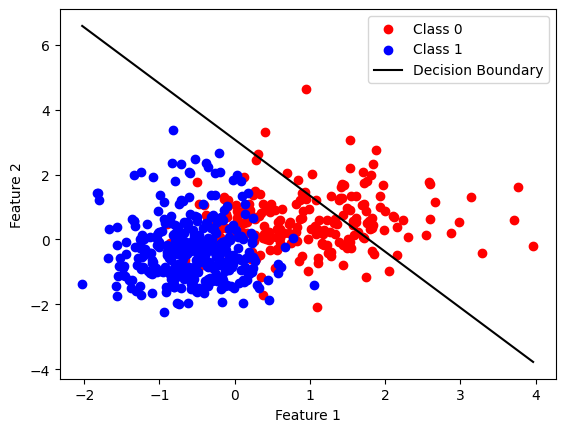

In [39]:
x = x.values
y = y.values

plt.scatter(x[y==0, 0], x[y==0, 1],
            color='red', label='Class 0')

# Class 1
plt.scatter(x[y==1, 0], x[y==1, 1],
            color='blue', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# create x1 values
x1_vals = np.linspace(x[:,0].min(), x[:,0].max(), 100)

# compute x2 values from boundary equation
x2_vals = -(w[0]*x1_vals + b) / w[1]

plt.plot(x1_vals, x2_vals, color='black', label='Decision Boundary')
plt.legend()
plt.show()

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [44]:
# ensure m and n match the training set to avoid indexing beyond X_train
m, n = X_train.shape
w, b = gradient_descent(X_train, y_train, learning_rate, iterations)


Cost: -0.17730011608788007
Cost: -0.07015499022467796
Cost: -0.02118633780100717
Cost: 0.01897972047183848
Cost: 0.05835113339685606
Cost: 0.08751080375498098
Cost: 0.11165543446876046
Cost: 0.13503817272528854
Cost: 0.1581993855587731
Cost: 0.18128453213420348


In [47]:
z_test = X_test.dot(w) + b
y_pred = (sigmoid(z_test) >= 0.5).astype(int)


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[40  3]
 [ 1 70]]


In [49]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)


Precision: 0.958904109589041


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

